In [4]:
import matplotlib.pyplot as plt
import math
import numpy as np

### About activation functions

The properties of activation functions may pose certain problems in neural networks. In this case we're categorizing inputs x=[-1, 1] to outputs y={-1, 1}. Using e.g. ReLU too soon you essentially kill neurons that pass values x<0. 

Also, tang and sigmoid derivatives tend towards 0 quickly when the input values go up, causing the gradients to saturate and vanish. Then the problem of depth, when you stack layers, you almost guarantee vanishing / exploding gradients if inputs or layers are not handled correctly.

Since increasing depth multiplies gradients repeatedly<img src="pics/kuva1.png" style="width:10%;">, if each derivative is say ~0.5, then for +.5**20 = ~10e-6. The problem of gradient saturation is slower optimization. Conversely, if gradients are large, the end result is the opposite and gradients grow too large, which causes overshoot and huge variance in backpropagation. So with wide network you risk saturation, and with deep network the prolem is amplified exponentially and vanishing is almost guaranteed.

Neurons whose input go to zero, grads go to zero, and can never recover, so ReLU is in essence freezing neurons if this is not taken into account.

So to fight saturation and explosion, proper initialization must be done by scaling and / or normalizing input, clipping gradients, normalizing layers or maybe using smaller learning rates.

<img src="pics/kuva2.png" style="width:50%;">

In [ ]:
# sigmoid functions

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sig_d(x):
    return sigmoid(x) * (1 - sigmoid(x))

In [36]:
# tanh functions

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def tanh_d(x):
    return 1 - tanh(x)**2

In [81]:
# relu function

def relu(x):
    return (x + abs(x)) / 2

def relu_d(x):
    if isinstance(x, np.ndarray):
        return (x > 0).astype(float)
    else:
        return (1 if x > 0 else 0)

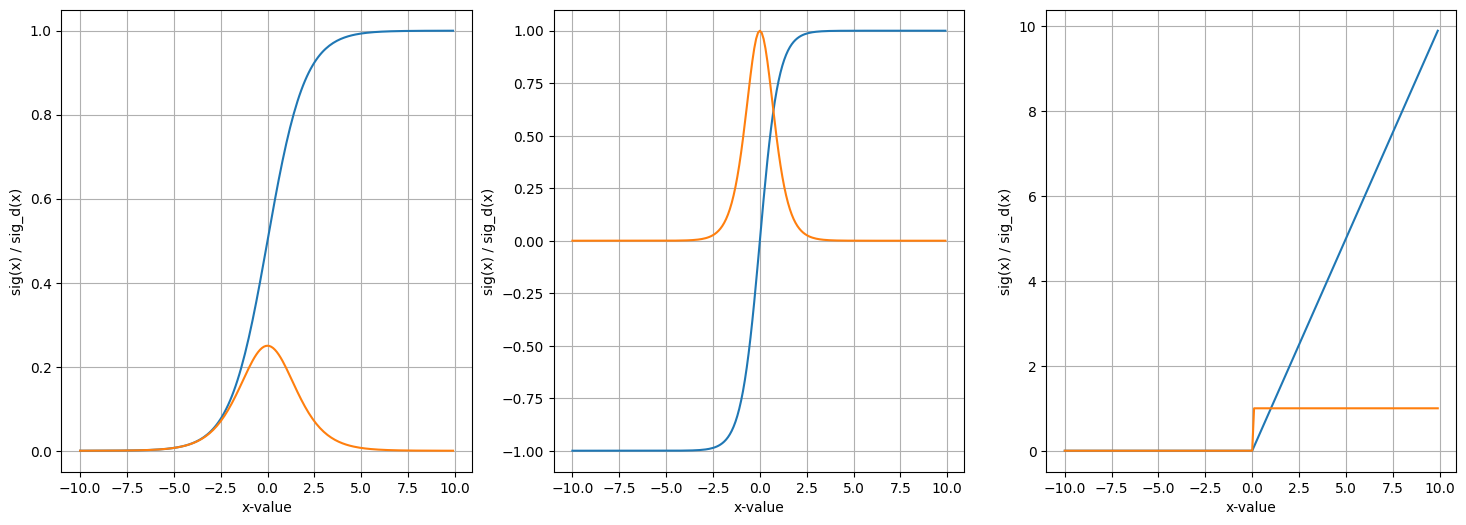

In [66]:
xs = np.arange(-10, 10, 0.1)

# sigmoid and sigmoid_d visualized

fig, ax = plt.subplots(1,3, figsize=(18, 6))

ax[0].plot(xs, sigmoid(xs))
ax[0].plot(xs, sig_d(xs))
ax[0].grid()
ax[0].set_xlabel('x-value')
ax[0].set_ylabel('sig(x) / sig_d(x)')

ax[1].plot(xs, tanh(xs))
ax[1].plot(xs, tanh_d(xs))
ax[1].grid()
ax[1].set_xlabel('x-value')
ax[1].set_ylabel('sig(x) / sig_d(x)')

ax[2].plot(xs, relu(xs))
ax[2].plot(xs, relu_d(xs))
ax[2].grid()
ax[2].set_xlabel('x-value')
ax[2].set_ylabel('sig(x) / sig_d(x)')

plt.show()

In [103]:
for i in range(-9, 9):
    print(f'Sigmoid: x={i}, grad: {sig_d(i):.5f} \ttanh: x={i}, grad: {tanh_d(i):.5f} \tReLU: x={i}, grad: {relu_d(i):.5f}')
print()
sig_d_max = max([sig_d(x) for x in xs])
tanh_d_max = max([tanh_d(x) for x in xs])

print(f'Max value for sig_d = {sig_d_max}\tMax value for tanh_d = {tanh_d_max}\tMax value for sig_d = 1')
print()
print('Grad at x=50')
print()
print(f'Sigmoid grad={sig_d(50)}\ttanh grad={tanh_d(50)}\tReLU grad={relu_d(50)}')

Sigmoid: x=-9, grad: 0.00012 	tanh: x=-9, grad: 0.00000 	ReLU: x=-9, grad: 0.00000
Sigmoid: x=-8, grad: 0.00034 	tanh: x=-8, grad: 0.00000 	ReLU: x=-8, grad: 0.00000
Sigmoid: x=-7, grad: 0.00091 	tanh: x=-7, grad: 0.00000 	ReLU: x=-7, grad: 0.00000
Sigmoid: x=-6, grad: 0.00247 	tanh: x=-6, grad: 0.00002 	ReLU: x=-6, grad: 0.00000
Sigmoid: x=-5, grad: 0.00665 	tanh: x=-5, grad: 0.00018 	ReLU: x=-5, grad: 0.00000
Sigmoid: x=-4, grad: 0.01766 	tanh: x=-4, grad: 0.00134 	ReLU: x=-4, grad: 0.00000
Sigmoid: x=-3, grad: 0.04518 	tanh: x=-3, grad: 0.00987 	ReLU: x=-3, grad: 0.00000
Sigmoid: x=-2, grad: 0.10499 	tanh: x=-2, grad: 0.07065 	ReLU: x=-2, grad: 0.00000
Sigmoid: x=-1, grad: 0.19661 	tanh: x=-1, grad: 0.41997 	ReLU: x=-1, grad: 0.00000
Sigmoid: x=0, grad: 0.25000 	tanh: x=0, grad: 1.00000 	ReLU: x=0, grad: 0.00000
Sigmoid: x=1, grad: 0.19661 	tanh: x=1, grad: 0.41997 	ReLU: x=1, grad: 1.00000
Sigmoid: x=2, grad: 0.10499 	tanh: x=2, grad: 0.07065 	ReLU: x=2, grad: 1.00000
Sigmoid: x=3,